# Analyse exploratoire des données (EDA)

L’objectif de cette analyse est de comprendre la structure des données, identifier les variables importantes et détecter les facteurs potentiellement liés au churn client.

Cette étape est essentielle pour orienter le preprocessing et le choix des modèles de machine learning.

## 1. Chargement des données

Nous commençons par importer les bibliothèques nécessaires et charger le dataset.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/raw/dataset.csv')

# Affichage des 5 premières lignes
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Structure des données

Cette étape permet d’identifier :
- le nombre d’observations et de variables ;
- les types de variables (numériques, catégorielles) ;
- la présence éventuelle de valeurs manquantes.

On remarque notamment que certaines variables numériques comme `TotalCharges` sont stockées comme des objets, ce qui nécessitera un traitement.

In [22]:
print(f"Dimensions du dataset : {df.shape}\n")

df.info()

Dimensions du dataset : (7043, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperl

## 4. Analyse descriptive

### Variables numériques

Les statistiques descriptives permettent d’avoir une première idée de la distribution des variables comme l’ancienneté (`tenure`) et les charges mensuelles (`MonthlyCharges`).

### Variable cible

La variable `Churn` indique si un client a quitté l’entreprise.
On observe la proportion de churn afin de vérifier si les classes sont équilibrées.

In [23]:
# Statistiques pour les variables numériques
display(df.describe())

# Pour voir la répartition de la variable cible
print("\nRépartition du Churn :")
display(df['Churn'].value_counts(normalize=True) * 100) # En pourcentage

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Répartition du Churn :


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

On observe un déséquilibre modéré : environ 27% des clients ont churné.
Ce point sera important pour le choix des métriques (le recall sera privilégié).

## 5. Nettoyage des données

La variable `TotalCharges` est actuellement au format texte et contient des valeurs vides.

Nous la convertissons en numérique, ce qui transforme les valeurs invalides en NaN, puis nous supprimons les lignes concernées.

In [24]:
# Conversion de TotalCharges en numérique (les espaces deviennent des NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Suppression des lignes contenant des valeurs manquantes dans TotalCharges
df = df.dropna(subset=['TotalCharges'])

## 6. Analyse des relations avec le churn

Nous analysons ici les variables les plus pertinentes en lien avec la variable cible.
L’objectif est d’identifier les facteurs pouvant expliquer le churn.

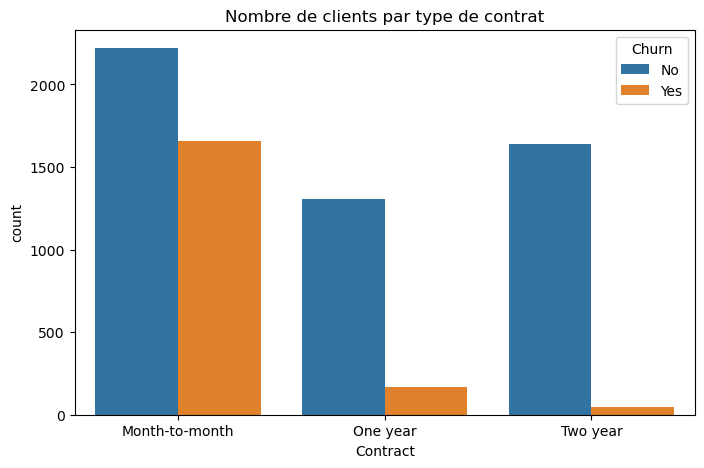

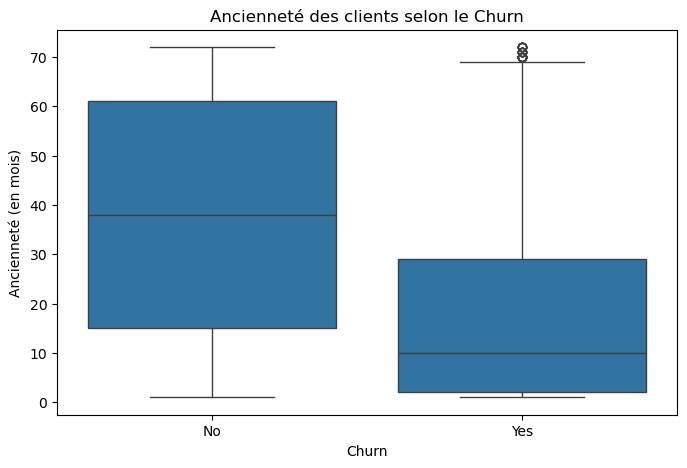

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Churn vs Type de Contrat (Countplot : compte simplement le nombre de personnes)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Nombre de clients par type de contrat')
plt.show()

# 2. Churn vs Ancienneté (Boxplot : montre la moyenne et la répartition)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Ancienneté des clients selon le Churn')
plt.ylabel('Ancienneté (en mois)')
plt.show()

**Contrat vs churn**

On observe que les clients avec un contrat mensuel ("Month-to-month") churnent beaucoup plus que ceux avec un contrat à long terme.

Cela suggère que l’engagement contractuel joue un rôle important dans la fidélisation.

**Ancienneté vs churn**

Les clients qui churnent ont en moyenne une ancienneté plus faible.

Cela indique que les nouveaux clients sont plus susceptibles de quitter l’entreprise, ce qui peut traduire un problème d’onboarding ou de satisfaction initiale.

## 7. Analyse des corrélations

La matrice de corrélation permet d’identifier les relations entre variables numériques.

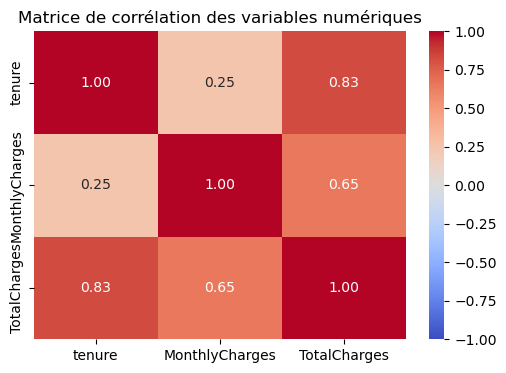

In [26]:
# Sélection des variables numériques
cols_num = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Calcul de la matrice de corrélation
corr_matrix = df[cols_num].corr()

# Affichage avec une Heatmap (carte de chaleur)
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matrice de corrélation des variables numériques')
plt.show()

On observe une forte corrélation entre `tenure` et `TotalCharges`, ce qui est logique puisque les charges totales augmentent avec le temps.

Ces informations sont utiles pour comprendre les relations entre variables mais ne suffisent pas à expliquer directement le churn.

## 8. Conclusion de l’EDA

Cette analyse exploratoire met en évidence plusieurs éléments importants :

- les clients récents churnent davantage ;
- les contrats mensuels sont associés à un taux de churn plus élevé ;
- certaines variables comme les charges et l’ancienneté sont fortement liées entre elles.

Ces observations guideront les étapes suivantes :
- le preprocessing des données ;
- le choix des variables ;
- la modélisation supervisée et non supervisée.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Séparation Features (X) / Target (y)
X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn']

# 2. Encodage de la Target (Exigence stricte de ton prof)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3. Split Train/Test (80% entrainement, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 4. Création de la Pipeline de Preprocessing
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ])

# 5. Création du Modèle complet (Preprocessing + Régression Logistique)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 6. Entraînement sur X_train et Prédiction sur X_test
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

# 7. Évaluation et affichage des métriques
print("--- RAPPORT DE CLASSIFICATION ---")
print(classification_report(y_test, y_pred, target_names=['No Churn (0)', 'Churn (1)']))

--- RAPPORT DE CLASSIFICATION ---
              precision    recall  f1-score   support

No Churn (0)       0.85      0.88      0.87      1033
   Churn (1)       0.64      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.80      1407



In [30]:
import joblib
import os

# Création du dossier models s'il n'existe pas
os.makedirs('models', exist_ok=True)

# Sauvegarde de la Pipeline complète (Preprocessing + Modèle)
joblib.dump(model_pipeline, '../models/model.pkl')

print("Modèle sauvegardé avec succès dans le dossier 'models/' !")

Modèle sauvegardé avec succès dans le dossier 'models/' !


In [31]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. On sélectionne uniquement les variables numériques pour faire nos groupes
X_num = df[['tenure', 'MonthlyCharges', 'TotalCharges']]

# 2. Obligatoire pour le K-Means : on remet toutes les valeurs à la même échelle
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# 3. Création de l'algorithme K-Means (on lui demande de faire 3 groupes/clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 4. On entraîne et on attribue immédiatement un numéro de groupe à chaque client
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. --- ANALYSE BUSINESS DES GROUPES ---
# On calcule la moyenne de chaque variable pour comprendre qui est dans quel groupe
cluster_summary = df.groupby('Cluster')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()
cluster_summary['Nombre_Clients'] = df['Cluster'].value_counts()

# On regarde si certains groupes ont naturellement plus tendance à résilier
cluster_summary['Taux_Churn_Reel (%)'] = df.groupby('Cluster')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

print("--- PROFIL DES CLUSTERS (SEGMENTATION) ---")
display(cluster_summary.round(2))

--- PROFIL DES CLUSTERS (SEGMENTATION) ---


,tenure,MonthlyCharges,TotalCharges,Nombre_Clients,Taux_Churn_Reel (%)
Cluster,,,,,
0,29.62,26.63,815.26,2151,12.32
1,58.57,89.74,5249.43,2197,15.38
2,13.26,74.97,1031.88,2684,47.17
